# Deep models interpretability
This notebooks shows examples of approaches for interpretation of (pre-)trained model predictions.

In [ ]:
try:
    import skimage
except ModuleNotFoundError:
    import subprocess as sp
    result = sp.run(
        ['pip3', 'install', 'scikit-image'],
        stdout=sp.PIPE, stderr=sp.PIPE
    )

    if result.returncode != 0:
        print(result.stdout.decode('utf-8'))
        print(result.stderr.decode('utf-8'))

    import skimage

In [ ]:
import urllib
import torch, torch.nn as nn
import torch.nn.functional as F
import torchvision.models

import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

### please, don't remove the following line
x = torch.tensor([1], dtype=torch.float32).to(device)

device: cuda


In [ ]:
# load imagenet class names
import requests
response = requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json')
class_labels = {int(key): value for key, (code, value) in response.json().items()}

In [ ]:
class_labels[897]

'washer'

### Task I: manual explanation with smoothgrad (1 point)

Let us begin by implementing our own little explainer for [DenseNet121](https://arxiv.org/abs/1608.06993) pretrained on ImageNet.

For the sake of simplicity, we're gonna rely on [SmoothGrad](https://arxiv.org/pdf/1706.03825.pdf) explainer - a simple average of gradients over noisy inputs.

In [ ]:
# model = torchvision.models.densenet121(pretrained=True).train(False).to(device)
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1).train(False).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.4MB/s]


data/img.jpg        100%[===================>]  50.53K  --.-KB/s    in 0.007s  


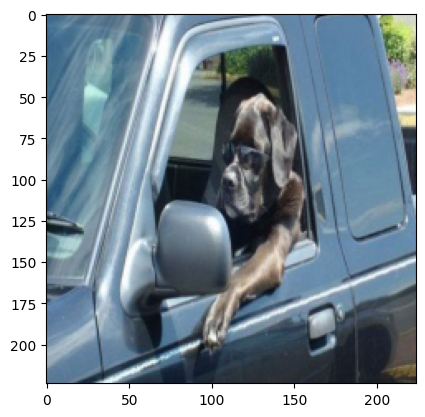

#1: p=0.853	bloodhound (163)
#2: p=0.039	washer (897)
#3: p=0.009	car_mirror (475)
#4: p=0.008	pickup (717)
#5: p=0.008	Weimaraner (178)
#6: p=0.007	Labrador_retriever (208)
#7: p=0.006	Chesapeake_Bay_retriever (209)
#8: p=0.005	limousine (627)
#9: p=0.004	pug (254)
#10: p=0.003	tub (876)


In [ ]:
!mkdir -p data
!wget -nc -q https://cdn2.adrianflux.co.uk/wp-fluxposure/uploads/2014/08/no-7.jpg -O data/img.jpg --show-progress

image = resize(plt.imread('data/img.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(image_tensor), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

Now let's implement SmoothGrad itself.

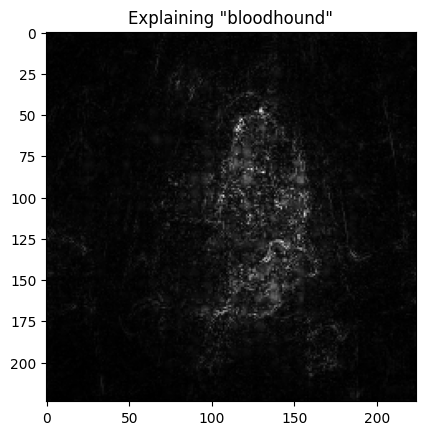

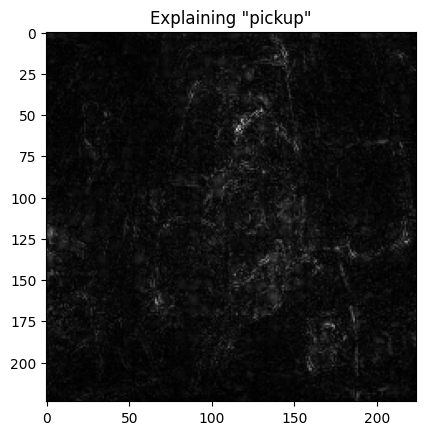

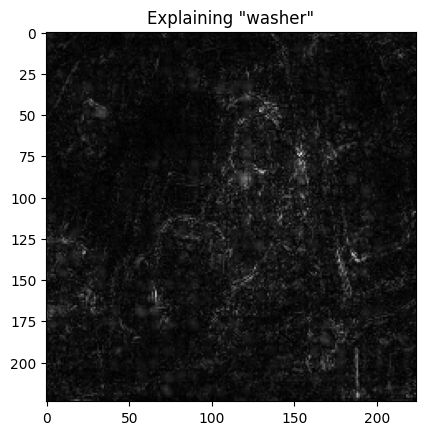

In [ ]:
import matplotlib as mpl

def explain_smoothgrad(image: torch.Tensor, class_ix: int, num_runs: int = 32, sigma: float = 0.1):
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)  # shape: [1, 3, h, w]
    image_tensor.requires_grad = True
    image_batch = image_tensor.repeat(num_runs, 1, 1, 1)  # shape [num_runs, no change, no change, no change]
    randomized_batch = image_batch + torch.randn_like(image_batch) * sigma

    # 1. create :num_runs: copies of an image
    # 2. apply independent random noise to each copy, use N(0, sigma) distribution
    # 3. compute gradients of logit for class_ix w.r.t. input pixels
    # 4. average these gradients across different images
    # 5. re-shape these gradients in the same shape as original image: (h, w, 3)

    mean_logprob_class = model(randomized_batch).log_softmax(dim=-1)[:, class_ix].mean()
    mean_logprob_class.backward()

    average_gradients = image_tensor.grad.squeeze(0).permute(1, 2, 0)

    assert tuple(average_gradients.shape) == image.shape
    return abs(average_gradients).sum(axis=2).cpu().numpy()

for class_ix in 163, 717, 897:  # <-- insert your classes here, use numbers in (brackets)
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    plt.imshow(explain_smoothgrad(image, class_ix), cmap=mpl.colormaps["grey"])
    plt.show()

__Let's try it out!__ Peter Higgs nobel prize photo

data/img2.jpg       100%[===================>] 167.99K  --.-KB/s    in 0.01s   


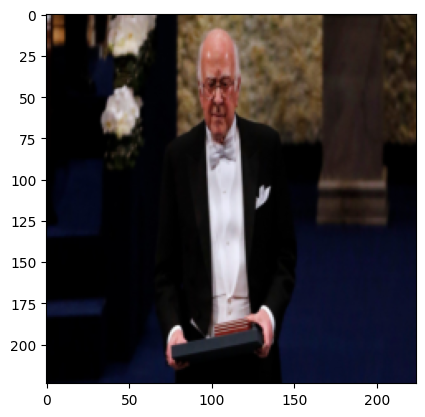

#1: p=0.211	suit (834)
#2: p=0.049	toilet_seat (861)
#3: p=0.040	plunger (731)
#4: p=0.032	vacuum (882)
#5: p=0.026	guillotine (583)
#6: p=0.024	balance_beam (416)
#7: p=0.023	academic_gown (400)
#8: p=0.022	torch (862)
#9: p=0.019	lab_coat (617)
#10: p=0.017	hook (600)


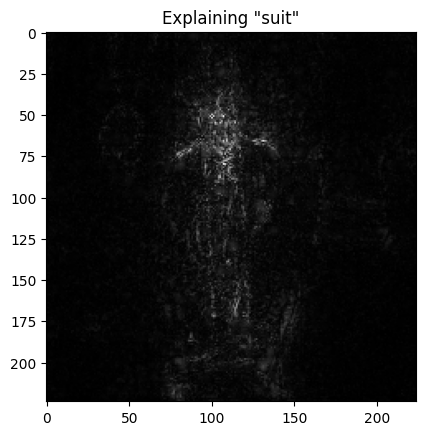

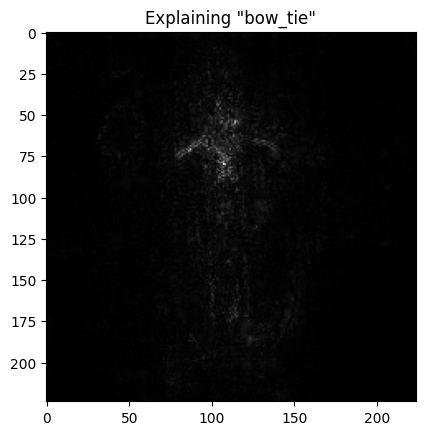

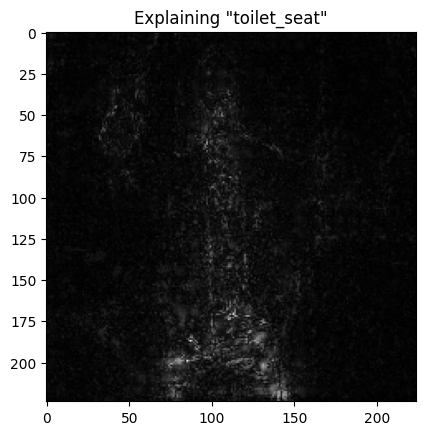

In [ ]:
!wget -nc -q https://i.pinimg.com/originals/3a/e1/83/3ae18369ab2e86be83e637ad702ec832.jpg -O data/img2.jpg --show-progress

image = resize(plt.imread('data/img2.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(image_tensor), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

for class_ix in 834, 457, 861:
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    plt.imshow(explain_smoothgrad(image, class_ix), cmap='gray')
    plt.show()

### SHapley Additive exPlanations
Now, let's try something heavier. The current state of the art in explaining model predictions is [SHAP](https://arxiv.org/abs/1705.07874): Shapley Additive Explanations.

This method is based on [Shapley values](https://en.wikipedia.org/wiki/Shapley_value) - a game-theoretic concept that evaluates the contribution of individual players in a cooperative game. Except this time our "players" are input features and the "game" is predicting whichever output the model gave.

Computing Shapley values naively requires $O(F!)$ time where F is the number of features. To make this computation more feasible, authors [proposed](https://arxiv.org/abs/1705.07874) several approximations, one of which relies on averaged gradients. This approximation also requires "background" data - other images similar to the ones in question that can be used as reference points.

In [ ]:
try:
    import shap
except ModuleNotFoundError:
    import subprocess as sp
    result = sp.run(
        ['pip3', 'install', 'shap'],
        stdout=sp.PIPE, stderr=sp.PIPE
    )

    if result.returncode != 0:
        print(result.stdout.decode('utf-8'))
        print(result.stderr.decode('utf-8'))

    import shap

In [ ]:
shap.initjs()

# load "background" images - some 50 random images from ImageNet
background, _ = shap.datasets.imagenet50()
background = torch.as_tensor(background / 255.0, device=device, dtype=torch.float32)
background = background.permute(0, 3, 1, 2)

In [ ]:
background.size()

torch.Size([50, 3, 224, 224])

In [ ]:
# image to explain
!wget -q -nc https://i.pinimg.com/originals/32/da/5c/32da5c3314fcc5ebf1a7b7d1548fcb03.jpg -O data/img3.jpg --show-progress
image = resize(plt.imread('data/img3.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)

data/img3.jpg       100%[===================>]  60.56K  --.-KB/s    in 0.002s  


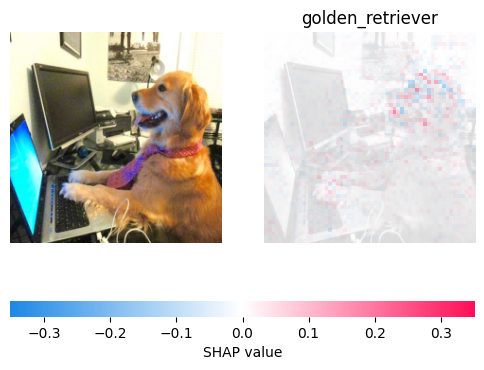

In [ ]:
# explain and visualize. If you're not using a powerful V100 GPU, this may take up to 20 minutes.
explainer = shap.GradientExplainer((model, model.layer1), background)
shap_values, indices = explainer.shap_values(image_tensor, ranked_outputs=5, nsamples=200)
shap_values = [np.transpose(values, (0, 1, 2, 3)) for values in shap_values]
index_names = np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy())
shap.image_plot(shap_values, image_tensor.permute(0, 2, 3, 1).cpu().numpy(), index_names)

data/img4.jpg       100%[===================>]  36.42K  --.-KB/s    in 0.007s  


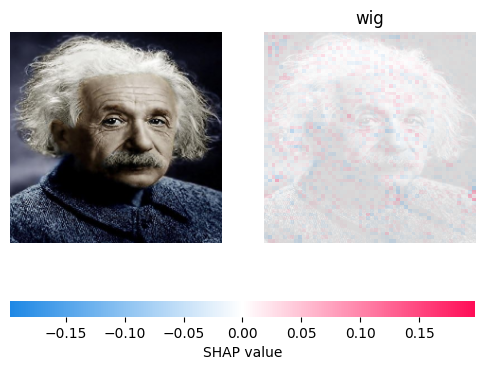

In [ ]:
# obligatory physicist reference
!wget -nc -q https://images-na.ssl-images-amazon.com/images/I/51ArQaCkkZL._AC_.jpg -O data/img4.jpg --show-progress
image = resize(plt.imread('data/img4.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)
explainer = shap.GradientExplainer((model, model.layer1), background)
shap_values, indices = explainer.shap_values(image_tensor, ranked_outputs=3, nsamples=200)
shap_values = [np.transpose(values, (0, 1, 2, 3)) for values in shap_values] # bruh
index_names = np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy())
shap.image_plot(shap_values, image_tensor.permute(0, 2, 3, 1).cpu().numpy(), index_names)

###### Explaining classical machine learning models

Finally, let's see how SHAP explainers can be applied to more conventional machine learning models like gradient boosting.

Spoiler: exactly the same from a user's perspective. However, this time we're gonna use a different Shapley approximation implemented in TreeExplainer. For a full set of available explainers, take a look at their official [examples page](https://github.com/slundberg/shap/tree/master/notebooks).

**NB: the following cells requires JavaScript support and should work in Jupyter (not JupyterLab or cocalc)**.
In that case try running it on Google colab: https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
import catboost
import shap

X, y = shap.datasets.california()

ensemble = catboost.CatBoostRegressor(iterations=100, learning_rate=0.1)
ensemble.fit(X, y, verbose=False, plot=False)
explainer = shap.TreeExplainer(ensemble)
shap_values = explainer.shap_values(X)

shap.initjs()

# visualize explanation of the first example
shap.force_plot(explainer.expected_value, shap_values[0, :], X.iloc[0, :])
#shap.save_html("force_plot.html", shap.force_plot(explainer.expected_value, shap_values, X))


In [ ]:
# Explain training data: each *column* is a rotated plot from above, stacked for all training samples
# (this plot is interactive, hover mouse to see feature names)
# shap.force_plot(explainer.expected_value, shap_values, X)

### Task II: Explain Intermediate Layers of Resnet50 on ImageNet (4 points)

Sometimes, computing explanations w.r.t. pixels is more difficult (and less interpretable) than using intermediate layers that are closer to the "output" layer. The trick is to compute low-resolution explanations of output w.r.t. intermediate layer and then resizing them to fit the original image.

Each layer in deep CNN learns filters of increasing complexity. The first layers learn basic feature detection filters such as edges and corners. The middle layers learn filters that detect parts of objects — for faces, they might learn to respond to features like eyes and brows, and deeper layers capture entire objects.

**Your task** is to explain ResNet50 model outputs with respect to the convolution module from 2nd  and 4th layer of the pretrained Resnet50 network using the same GradientExplainer. *The task may require some googling or browsing the [docs](https://shap.readthedocs.io/en/latest) :)*

**Please use at least 10 images from across the internet (or from ImageNet) and compare the 2nd and 4th layer explanations on these images.**


In [4]:
# Download all the pictures
import os

data_path = os.path.join("data", "task2", "img")

urls = [
    "https://wompimages.ampify.care/fetchimage?siteId=7575&v=2&jpgQuality=100&width=700&url=https%3A%2F%2Fi.kym-cdn.com%2Fentries%2Ficons%2Ffacebook%2F000%2F054%2F270%2Frigrig.jpg",
    "https://yt3.googleusercontent.com/ytc/AIdro_n0NvDVc-Xfe-1UTl4YhU7n9ZjE-ycsFhDsolyE4MtZ=s900-c-k-c0x00ffffff-no-rj",
    "https://i.natgeofe.com/k/825bd6d8-6daf-4019-8cab-9b4ed6c02545/tyrannosaurus-rex-closeup-jaws-walking_square.jpg",
    "https://i.pinimg.com/736x/a6/fa/46/a6fa46cd3655fb1a1fdc1f4a94babc06.jpg",
    "https://geniuses.club/public/storage/028/153/104/108/360_360_60714cfecb479.jpg",
    "https://us.v-cdn.net/6036147/uploads/67SAKXLFNL4I/l-10-8-1-1200x675.jpg",
    "https://dynamic-media-cdn.tripadvisor.com/media/photo-o/13/d5/6c/a8/photo1jpg.jpg?w=900&h=500&s=1",
    "https://www.parrotworld.fr/en/m_enhance/154?filename=perroquets-entrelaces&ext=jpg&style_name=gallery_image_large_1308_1088&h=544&w=654&rule=654w",
    "https://media.wired.com/photos/6669dda110a8c9fbd8bf87c3/4:3/w_1140,h_855,c_limit/Indie-Horror-Game_SIGNALIS-Rose-Engine%202.jpg",
    "https://www.gnu.org/graphics/reiss-head.jpg",
    "https://cdn.britannica.com/52/11452-050-AFAECE68/wildebeest.jpg",
    "https://www.allugandasafaris.com/wp-content/uploads/2024/07/giant-eland.jpg"
]

urls = [url.replace("&", "\&") for url in urls]
urls = [url.replace("=", "\=") for url in urls]
urls = [url.replace("?", "\?") for url in urls]

!mkdir -p {os.path.join("data", "task2")}

for idx, pic_url in enumerate(urls):
    pic_rel_path = f"{data_path}{idx}.jpg"
    !wget -nc -q {pic_url} -O {pic_rel_path} --show-progress

<>:21: SyntaxWarning: invalid escape sequence '\&'
<>:22: SyntaxWarning: invalid escape sequence '\='
<>:23: SyntaxWarning: invalid escape sequence '\?'
<>:21: SyntaxWarning: invalid escape sequence '\&'
<>:22: SyntaxWarning: invalid escape sequence '\='
<>:23: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipython-input-3516325213.py:21: SyntaxWarning: invalid escape sequence '\&'
  urls = [url.replace("&", "\&") for url in urls]
/tmp/ipython-input-3516325213.py:22: SyntaxWarning: invalid escape sequence '\='
  urls = [url.replace("=", "\=") for url in urls]
/tmp/ipython-input-3516325213.py:23: SyntaxWarning: invalid escape sequence '\?'
  urls = [url.replace("?", "\?") for url in urls]


img0.jpg → layer2


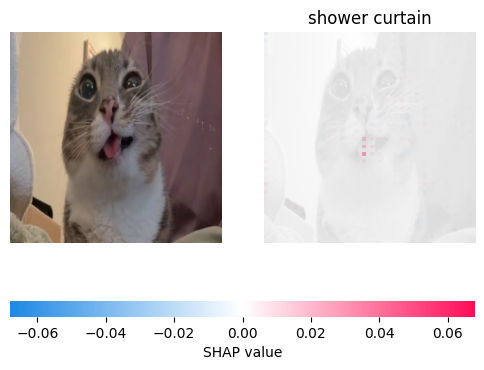

img0.jpg → layer4


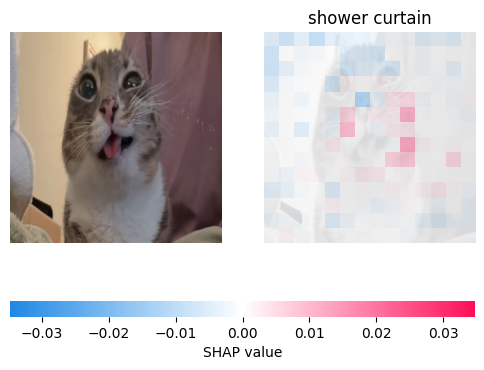

img1.jpg → layer2


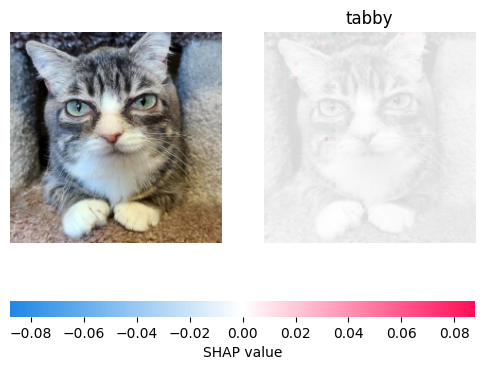

img1.jpg → layer4


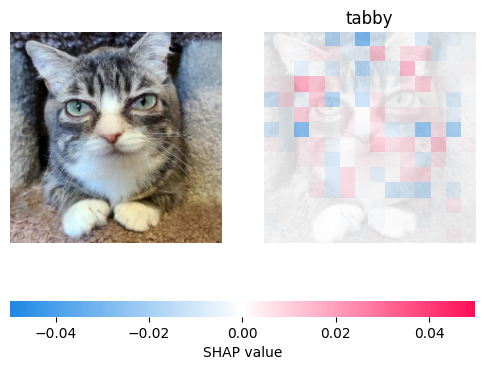

img10.jpg → layer2


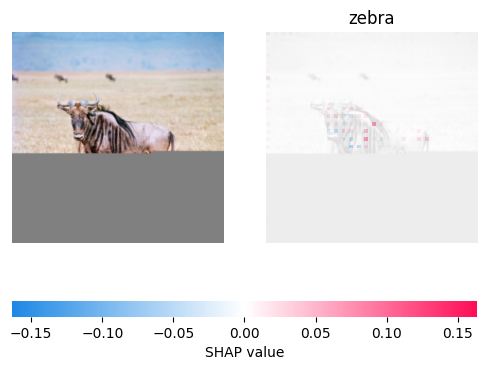

img10.jpg → layer4


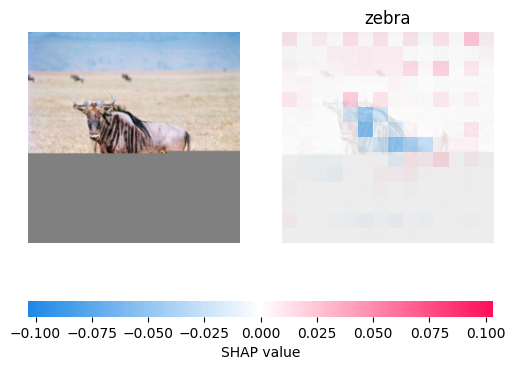

img11.jpg → layer2


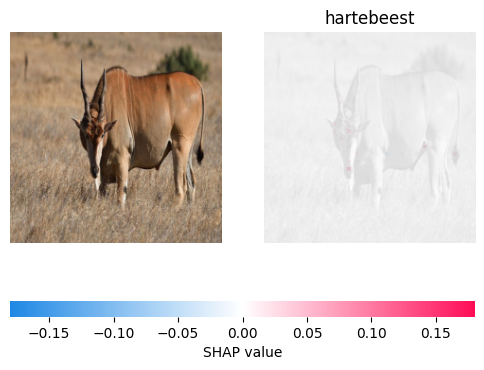

img11.jpg → layer4


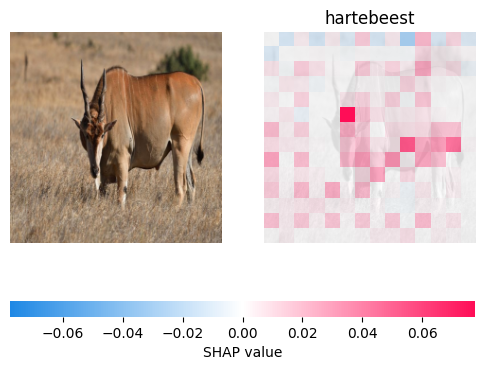

img2.jpg → layer2


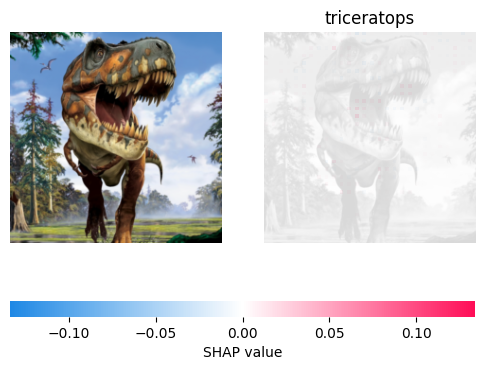

img2.jpg → layer4


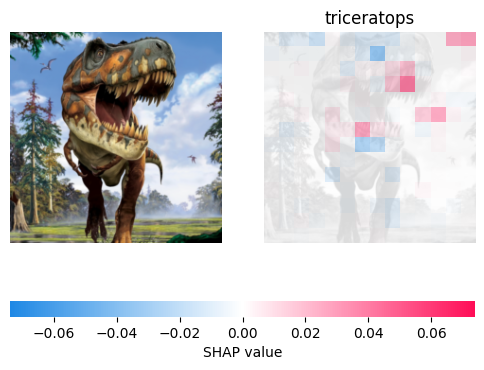

img3.jpg → layer2


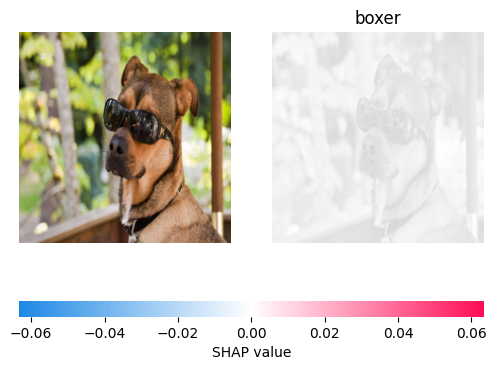

img3.jpg → layer4


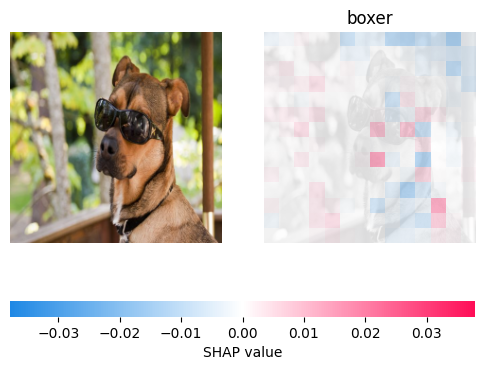

img4.jpg → layer2


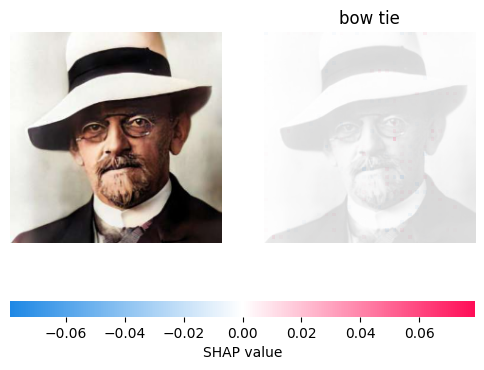

img4.jpg → layer4


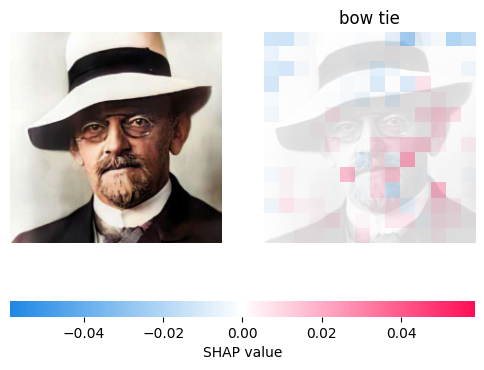

img5.jpg → layer2


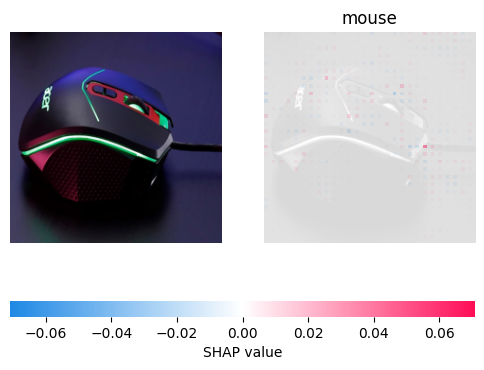

img5.jpg → layer4


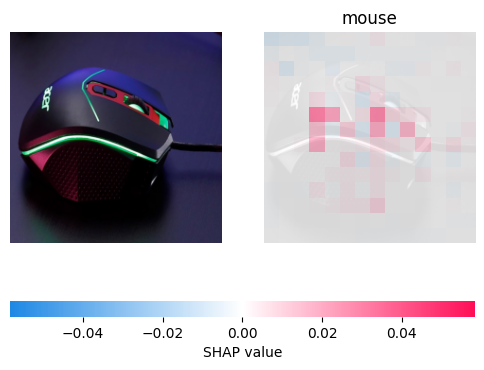

img6.jpg → layer2


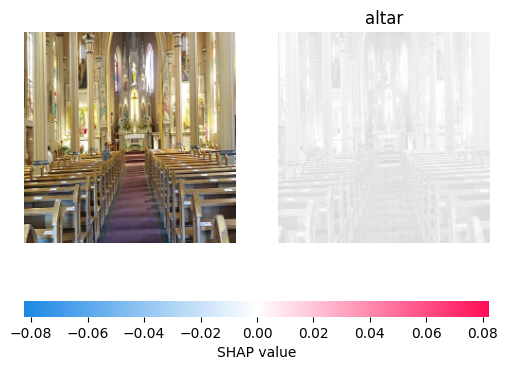

img6.jpg → layer4


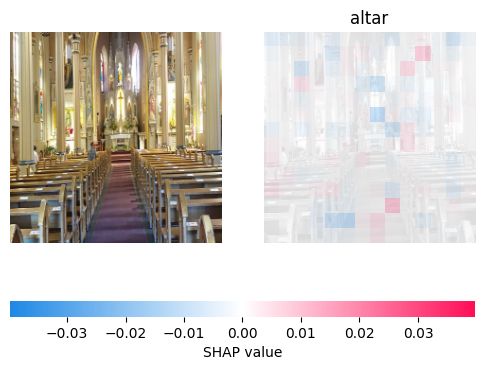

img7.jpg → layer2


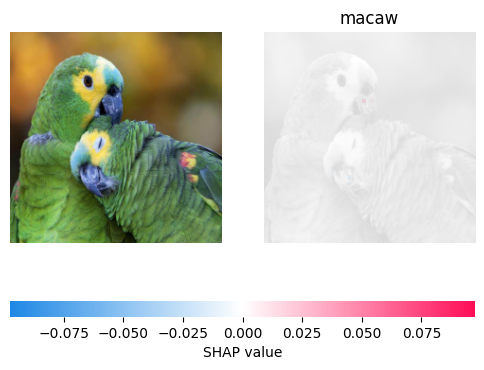

img7.jpg → layer4


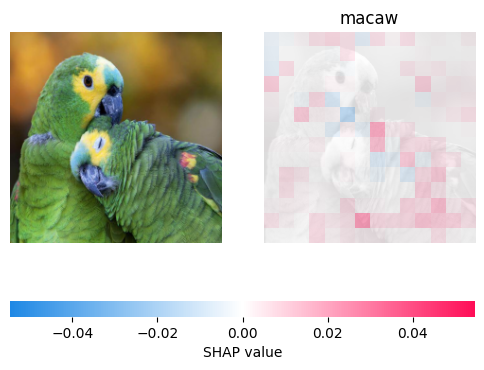

img8.jpg → layer2


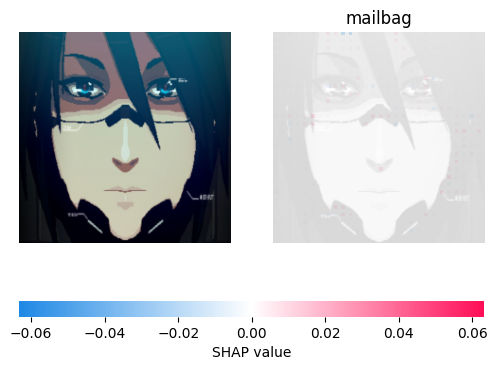

img8.jpg → layer4


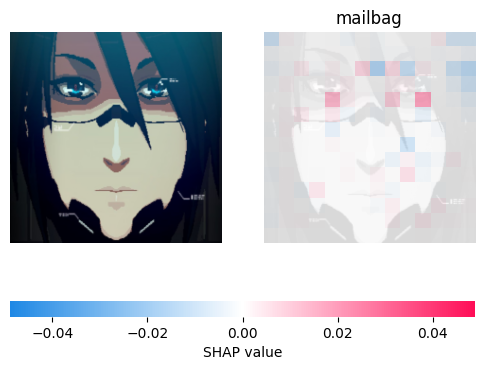

skip img9.jpg: cannot identify image file 'data/task2/img9.jpg'


In [14]:
import os
import torch
import torchvision
import shap
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from PIL import ImageFile
import pathlib

ImageFile.LOAD_TRUNCATED_IMAGES = True  # allow partially downloaded images

data_path = "data/task2/img"
pic_paths = sorted(pathlib.Path(".").glob(data_path + "*.jpg"))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = torchvision.models.resnet50(
    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1
).eval().to(device)
class_labels = torchvision.models.ResNet50_Weights.IMAGENET1K_V1.meta["categories"]

background = torch.zeros((1, 3, 224, 224), device=device)
explainer2 = shap.GradientExplainer((model, model.layer2), background)
explainer4 = shap.GradientExplainer((model, model.layer4), background)

for idx, path in enumerate(pic_paths):
    try:
        img = resize(plt.imread(path)[..., :3] / 255.0, (224, 224))
    except Exception as e:
        print(f"skip {path.name}: {e}")
        continue

    x = torch.as_tensor(img[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)

    for explainer, name in [(explainer2, "layer2"), (explainer4, "layer4")]:
        shap_values, indices = explainer.shap_values(x, ranked_outputs=3, nsamples=200)
        shap_values = [np.transpose(v, (0, 1, 2, 3)) for v in shap_values]
        labels = np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy())
        print(f"{path.name} → {name}")
        shap.image_plot(shap_values, x.permute(0, 2, 3, 1).cpu().numpy(), labels)

Layer 2 produces the largest (by magnitude) SHAP values for fine-grained features such as a cat’s nose, eyes, or fur patterns, while layer 4 responds to broader, higher-level structures — for example, horns in the GNU logo (resembling a nautilus shell), the wings and feathers of a parrot, or the background grass in images of grazing animals

## References

* SHAP explainer based on superpixels - [notebook](https://slundberg.github.io/shap/notebooks/ImageNet%20VGG16%20Model%20with%20Keras.html)
* SHAP reference notebook - [view on github](https://github.com/slundberg/shap/tree/master/notebooks)
* More various explainers in [ELI5](https://github.com/TeamHG-Memex/eli5)
* Same notebook on Google [Colab](https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb)